Calculates Lyapunov for Parkinson's Diseased Patients (CGA data)

define the functions 

In [26]:
import numpy as np
import xarray as xr
from pathlib import Path
from scipy.signal import detrend, butter, filtfilt
import matplotlib.pyplot as plt


# 1) Preprocessing: detrend, band‐pass, and z‐score
def preprocess_signal(ts: np.ndarray,
                   fs: float = 100.0,
                   low_bp: float = 0.1,
                   high_bp: float = 5.0,
                   low_lp: float = 10.0,
                   do_zscore: bool = False) -> np.ndarray:
    """
    Preprocess a mediolateral COM (in mm) time series.
    
    Steps:
      1) Remove linear trend (detrend).
      2) Apply a gentle low-pass at `low_lp` Hz to remove >10 Hz noise.
      3) Apply a band-pass between `low_bp`–`high_bp` Hz to keep step frequency.
      4) Optionally zero-mean & unit-variance (z-score).
    
    Inputs:
      ts      : 1D np.ndarray of COM_x values in millimeters.
      fs      : Sampling frequency (default 100 Hz).
      low_bp  : Lower cutoff for band-pass (default 0.1 Hz).
      high_bp : Upper cutoff for band-pass (default 5.0 Hz).
      low_lp  : Cutoff for low-pass (default 10.0 Hz).
      do_zscore : If True, z-score the final output.
    
    Returns:
      ts_out  : Preprocessed 1D array, same length as input.
    """
    # 1) Detrend
    ts_dt = detrend(ts)

    # 2) Gentle low-pass at low_lp Hz
    nyq = fs / 2.0
    b_lp, a_lp = butter(N=4, Wn=(low_lp/nyq), btype='low')
    ts_lp = filtfilt(b_lp, a_lp, ts_dt)

    # 3) Band-pass from low_bp to high_bp Hz
    b_bp, a_bp = butter(N=4, Wn=[low_bp/nyq, high_bp/nyq], btype='bandpass')
    ts_bp = filtfilt(b_bp, a_bp, ts_lp)

    # 4) (Optional) Z-score
    if do_zscore:
        ts_out = (ts_bp - np.mean(ts_bp)) / np.std(ts_bp)
    else:
        ts_out = ts_bp

    return ts_out



# 2) Average Mutual Information with quantile bins
def average_mutual_information(ts: np.ndarray, lag: int, bins: int = 64) -> float:
    """
    Compute AMI I(lag) between x(t) and x(t+lag) using equal‐occupancy bins.
    """
    edges = np.quantile(ts, np.linspace(0, 1, bins+1))
    x, y = ts[:-lag], ts[lag:]
    hist2d, _, _ = np.histogram2d(x, y, bins=[edges, edges])
    pxy = hist2d / np.sum(hist2d)
    px = np.sum(pxy, axis=1)
    py = np.sum(pxy, axis=0)
    mask = pxy > 0
    return np.sum(pxy[mask] * np.log(pxy[mask] / (px[:, None] * py[None, :])[mask]))


def optimal_lag(ts: np.ndarray,
                fs: float = 100.0,
                max_lag: int = 50,
                bins: int = 64) -> int:
    """
    Find a single, adaptive delay τ for embedding via Average Mutual Information (AMI),
    suitable for both healthy and Parkinson's gait.

    Steps:
      1) Compute AMI(τ) for τ = 1…max_lag.
      2) Plot AMI vs. τ with the AMI(1)/e threshold for visual check.
      3) Search for the first “filtered mild local minimum,” but only up to τ ≤ 0.20·fs:
           • AMI[i] ≤ AMI[i−1]  AND  AMI[i] ≤ AMI[i+1]
           • AND (AMI[i] ≤ 0.80·AMI(1)   OR   AMI[i] ≤ 0.90·AMI[i−1])
        (This prevents the algorithm from choosing a very small τ unless AMI has already
         dropped by ≥ 20% of AMI(1).)
      4) If no acceptable knee appears by τ = ⌊0.20·fs⌋, fallback to the first τ ≤ ⌊0.20·fs⌋
         where AMI(τ) ≤ AMI(1)/e.
      5) If nothing qualifies by τ = ⌊0.20·fs⌋, return the global‐minimum lag over 1…max_lag.
    """
    # 1) Compute AMI for τ = 1…max_lag
    ami_vals = [average_mutual_information(ts, lag, bins)
                for lag in range(1, max_lag + 1)]
    lags = np.arange(1, max_lag + 1)
    ami1 = ami_vals[0]

    # 2) Plot AMI vs. τ (optional, but good to inspect)
    plt.figure(figsize=(5, 3))
    plt.plot(lags, ami_vals, '-o', label='AMI(τ)')
    plt.axhline(ami1 / np.e, color='r', linestyle='--', label='AMI(1)/e')
    plt.xlabel('Lag (samples)')
    plt.ylabel('AMI')
    plt.title('AMI vs. Lag')
    plt.grid(True)
    plt.legend()
    plt.tight_layout()
    plt.show()

    # 3) Define a hard cutoff at τ_max = floor(0.20 * fs).  At 100 Hz, that is τ_max = 20.
    τ_max = min(max_lag, int(0.20 * fs))  # e.g. 20 if fs=100

    # If τ_max < 3 we can’t form a “local minimum” search, so just skip to fallback
    if τ_max < 3:
        return 1

    # 4) Look for the first “filtered mild local minimum” among τ = 2 … (τ_max - 1)
    #    (Indices i = 1 … (τ_max - 2) correspond to τ = i+1 = 2 … (τ_max-1))
    for i in range(1, τ_max - 1):  # i+1 ranges from 2 to τ_max-1
        if ami_vals[i] <= ami_vals[i - 1] and ami_vals[i] <= ami_vals[i + 1]:
            τ_candidate = i + 1  # because ami_vals[0] is τ=1
            # 4a) If τ_candidate is small (<5), only accept it if AMI has fallen by ≥20%
            if τ_candidate < 5:
                if ami_vals[i] <= 0.80 * ami1:
                    return τ_candidate
                else:
                    # Too shallow a drop at a very small τ—ignore it
                    continue
            # 4b) If τ_candidate ≥ 5, accept it unconditionally
            return τ_candidate

    # 5) Fallback #1: first τ ≤ τ_max where AMI(τ) ≤ AMI(1)/e
    threshold = ami1 / np.e
    for i in range(τ_max):  # i corresponds to τ = i+1
        if ami_vals[i] <= threshold:
            return i + 1

    # 6) Fallback #2: global minimum over τ = 1…max_lag
    return int(np.argmin(ami_vals) + 1)


def compute_fnn_percentage(ts: np.ndarray, lag: int,
                           max_dim: int = 15, rtol: float = 0.15):
    """
    Compute % of false nearest neighbors for embedding dims from 1 to max_dim.
    """
    N = len(ts)
    dims = np.arange(1, max_dim + 1)
    fnn_perc = np.zeros_like(dims, dtype=float)

    for idx, m in enumerate(dims):
        M = N - m * lag
        if M <= 0:
            fnn_perc[idx:] = np.nan
            break
        # Build m-dimensional delay vectors
        embedded = np.vstack([ts[i * lag : i * lag + M] for i in range(m)]).T
        false = total = 0
        for i in range(M):
            # compute distances to all other points
            dists = np.linalg.norm(embedded - embedded[i], axis=1)
            dists[i] = np.inf
            # exclude temporally too-close points
            dists[max(0, i - m * lag) : i + m * lag] = np.inf
            j = np.argmin(dists)
            if dists[j] == np.inf:
                continue
            d_extra = abs(ts[i + m * lag] - ts[j + m * lag])
            if d_extra / dists[j] > rtol:
                false += 1
            total += 1
        fnn_perc[idx] = false / total if total else np.nan

    return dims, fnn_perc


# 5) Optimal embedding dimension by “elbow” / max second‐difference
def optimal_embedding_dimension(ts: np.ndarray,
                                lag: int,
                                max_dim: int = 15,
                                rtol: float = 0.15) -> int:
    """
    Choose embedding dimension m by finding the 'elbow' in the FNN% curve:
      1) Compute FNN% for m = 1…max_dim
      2) Take the second discrete difference of the fnn% array
      3) Return the dimension m corresponding to the index of maximal |second_difference|

    This follows the theoretical idea that the largest curvature (elbow) in the FNN% vs. m
    plot is the best embedding dimension when no fixed threshold is applied.
    """
    dims, fnn = compute_fnn_percentage(ts, lag, max_dim, rtol)

    # If there's only one dimension or fnn cannot be computed, just return max_dim
    if len(dims) < 3 or np.all(np.isnan(fnn)):
        return max_dim

    # Compute second discrete difference of the FNN% curve
    # second_diff[i] = fnn[i] - 2*fnn[i+1] + fnn[i+2], where i = 0..(len(fnn)-3)
    second_diff = np.diff(fnn, n=2)

    # If all second_diff are NaN or zero, fallback to max_dim
    if np.all(np.isnan(second_diff)) or np.allclose(second_diff, 0, equal_nan=True):
        return max_dim

    # Find the index of maximum absolute curvature
    # Since second_diff is length (max_dim - 2), its index i corresponds to m = i + 2
    i_elbow = int(np.nanargmax(np.abs(second_diff)))
    m_elbow = i_elbow + 2

    # Ensure we do not exceed max_dim
    if m_elbow < 1:
        return 1
    if m_elbow > max_dim:
        return max_dim
    return m_elbow


visualize the data shortly

In [21]:
import argparse
from pathlib import Path
import numpy as np
import xarray as xr
import sys
import os
import matplotlib.pyplot as plt
cwd = Path.cwd()
print("Current working directory:", cwd)
file_path = cwd.parent / "../data"/"CGA"/"01"/"PWS"/"4" /"markers.nc"
print("Resolved file path:       ", file_path.resolve())
print("File exists?:             ", file_path.exists())
markers= xr.open_dataarray(file_path)
com= markers.sel(channel="COM")


%matplotlib widget

Current working directory: c:\Users\Natascha\OneDrive - Hochschule Luzern\Thesis_Dokus\DART\RepoCode\python-gaitalytics\nonlinear-metrics-calculation
Resolved file path:        C:\Users\Natascha\OneDrive - Hochschule Luzern\Thesis_Dokus\DART\RepoCode\data\CGA\01\PWS\4\markers.nc
File exists?:              True


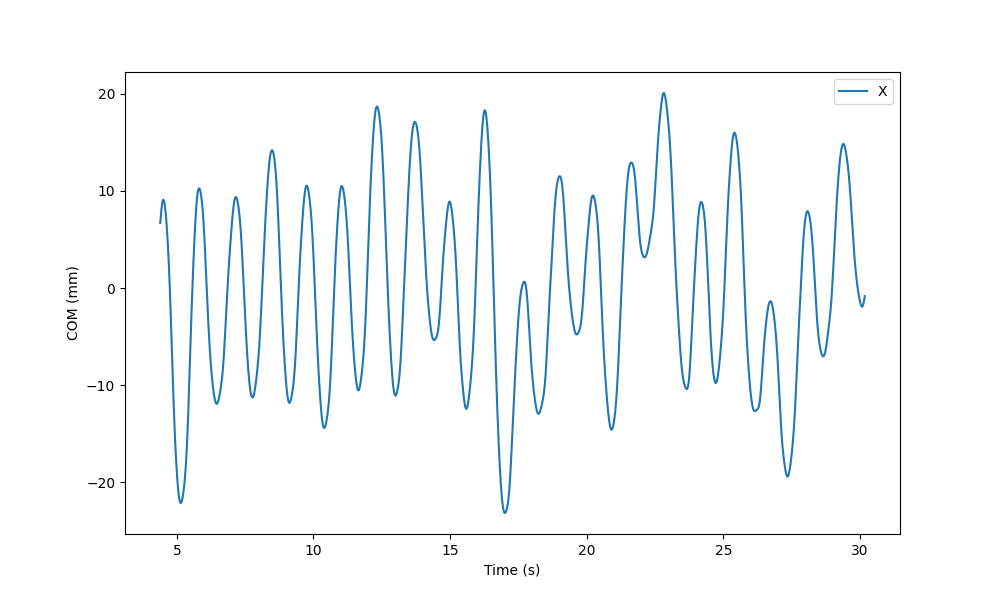

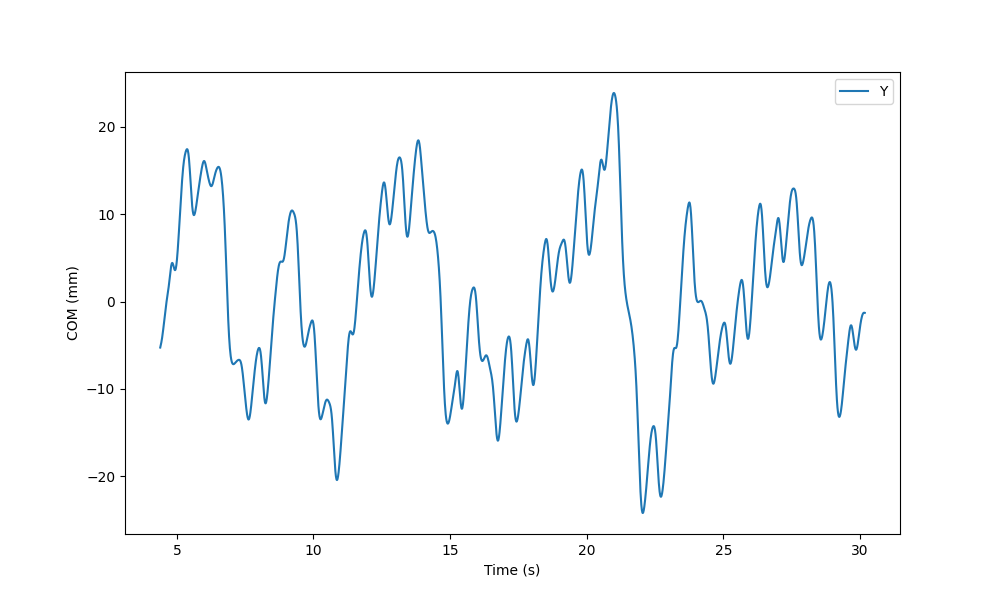

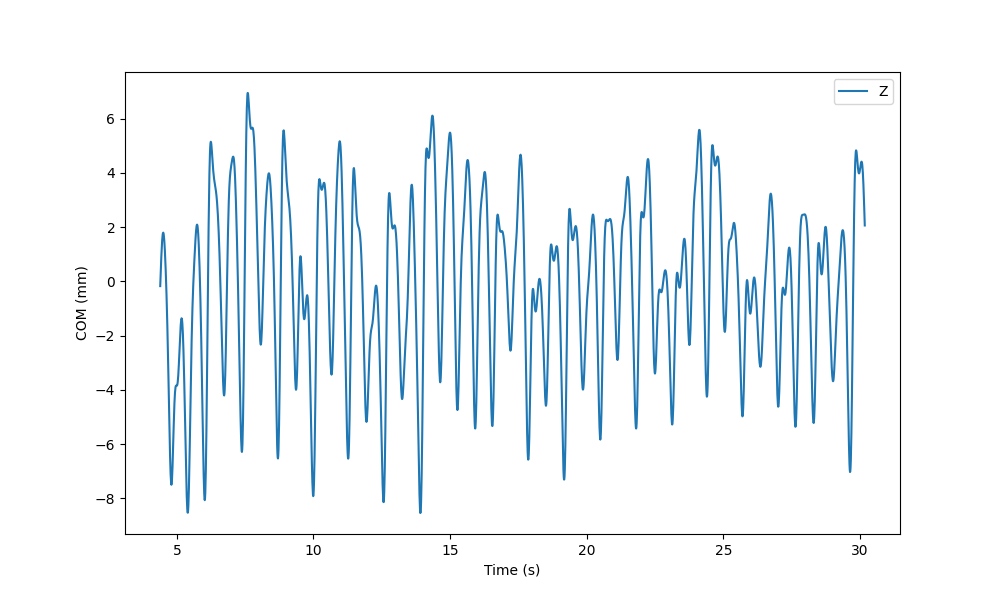

In [22]:
time = com.coords["time"].values      
x    = preprocess_signal (com.sel(axis="x").values)       
y    = preprocess_signal(com.sel(axis="y").values)
z    = preprocess_signal(com.sel(axis="z").values)

# x    = com.sel(axis="x").values  
# y    = com.sel(axis="y").values
# z    = com.sel(axis="z").values
# 1) X vs. time
fig = plt.figure(figsize=(10, 6))      
ax = fig.add_subplot(1, 1, 1)
ax.plot(time, x, label="X")
ax.set_xlabel("Time (s)")
ax.set_ylabel("COM (mm)")
ax.legend()
plt.show()

# 2) Y vs. time
fig = plt.figure(figsize=(10, 6))
ax = fig.add_subplot(1, 1, 1)
ax.plot(time, y, label="Y")
ax.set_xlabel("Time (s)")
ax.set_ylabel("COM (mm)")
ax.legend()
plt.show()

# 3) Z vs. time
fig = plt.figure(figsize=(10, 6))
ax = fig.add_subplot(1, 1, 1)
ax.plot(time, z, label="Z")
ax.set_xlabel("Time (s)")
ax.set_ylabel("COM (mm)")
ax.legend()
plt.show()

define the fit windows for the coefficient fit itself

In [34]:
def compute_lyapunov_exponent_16(ts: np.ndarray, emb_dim: int, lag: int,
                                 fs: float = 100.0, max_time: float = 5.0,
                                 fit_start: float = 0.0, fit_end: float = 1.2) -> float:
    """
    Compute short‐term Lyapunov exponent λ* by tracking divergence of nearest neighbors.
    Fit ⟨ln d(t)⟩ vs. t over the interval [fit_start, fit_end] (in seconds).

    Parameters:
      ts         : 1D time series (e.g. COM trajectory)
      emb_dim    : embedding dimension m
      lag        : embedding lag τ (in samples)
      fs         : sampling frequency (Hz), default 100.0
      max_time   : maximum divergence tracking window (seconds), default 5.0
      fit_start  : start of fitting window (seconds), default 0.0
      fit_end    : end of fitting window (seconds), default 1.2

    Returns:
      Estimated short‐term Lyapunov exponent (s⁻¹) as the slope of the linear fit
      to ⟨ln(distance)⟩ vs. time over [fit_start, fit_end]. Returns np.nan if
      insufficient data.
    """
    N = len(ts)
    M = N - (emb_dim - 1) * lag
    if M <= 0:
        return np.nan

    embedded = np.vstack([ts[i * lag : i * lag + M] for i in range(emb_dim)]).T
    min_sep = emb_dim * lag
    divergence = []

    for i in range(M):
        dists = np.linalg.norm(embedded - embedded[i], axis=1)
        dists[i] = np.inf
        dists[max(0, i - min_sep) : i + min_sep] = np.inf
        j = np.argmin(dists)
        if dists[j] == np.inf:
            continue

        k_max = min(M - i, M - j, int(max_time * fs))
        for k in range(1, k_max):
            d = np.linalg.norm(embedded[i + k] - embedded[j + k])
            if d > 0:
                divergence.append((k / fs, np.log(d)))

    if not divergence:
        return np.nan

    data = np.array(divergence)
    times, logs = data[:, 0], data[:, 1]

    # Bin and average
    bins = np.linspace(0, max_time, 50)
    centers, means = [], []
    for b in range(len(bins) - 1):
        mask = (times >= bins[b]) & (times < bins[b + 1])
        if mask.any():
            centers.append((bins[b] + bins[b + 1]) / 2)
            means.append(logs[mask].mean())

    centers = np.array(centers)
    means = np.array(means)

    # Plot divergence curve for inspection
    plt.figure()
    plt.plot(centers, means, 'o-')
    plt.axvline(fit_start, color='r', linestyle='--', label=f'{fit_start:.1f} s')
    plt.axvline(fit_end,   color='r', linestyle='--', label=f'{fit_end:.1f} s')
    plt.xlabel('Time (s)')
    plt.ylabel('Average ln(distance)')
    plt.title('Divergence curve')
    plt.grid(True)
    plt.legend()
    plt.show()

    # Fit over fit_start…fit_end
    fit_mask = (centers >= fit_start) & (centers <= fit_end)
    if fit_mask.sum() < 2:
        return np.nan

    slope, _ = np.polyfit(centers[fit_mask], means[fit_mask], 1)
    return slope


Current working directory: c:\Users\Natascha\OneDrive - Hochschule Luzern\Thesis_Dokus\DART\RepoCode\python-gaitalytics\nonlinear-metrics-calculation
Resolved file path:        C:\Users\Natascha\OneDrive - Hochschule Luzern\Thesis_Dokus\DART\RepoCode\data\CGA\01\PWS\4\markers.nc
File exists?:              True
Time coordinates: 4.39 to 30.18
Selected COM shape: (3, 2133)
Time range: 8.86 to 30.18


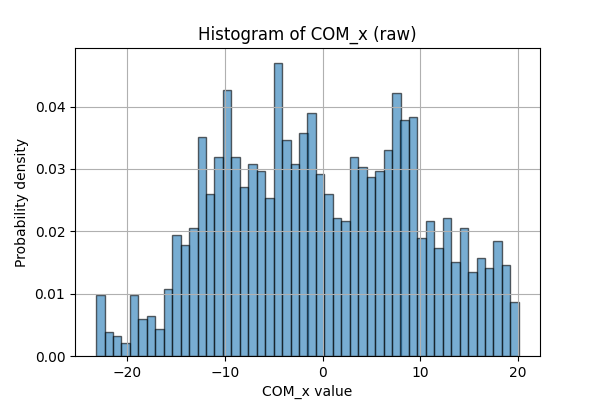

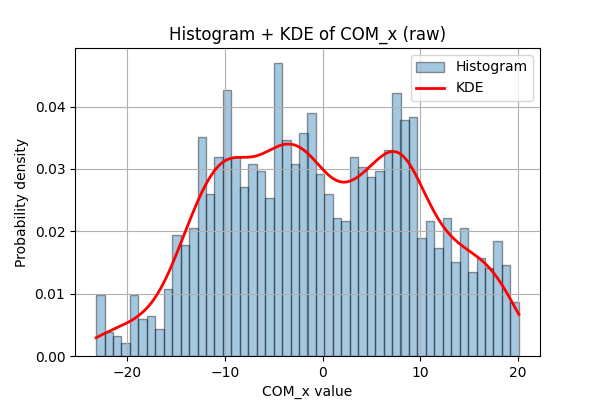

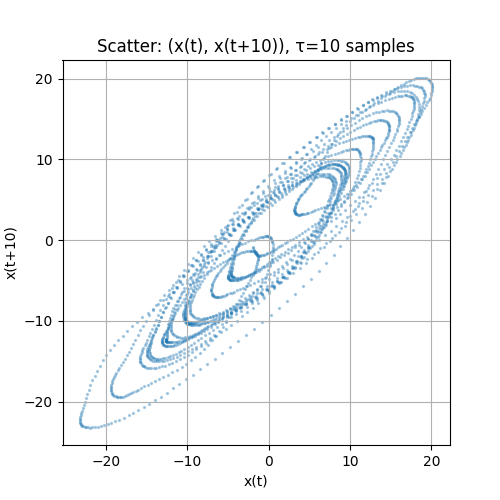

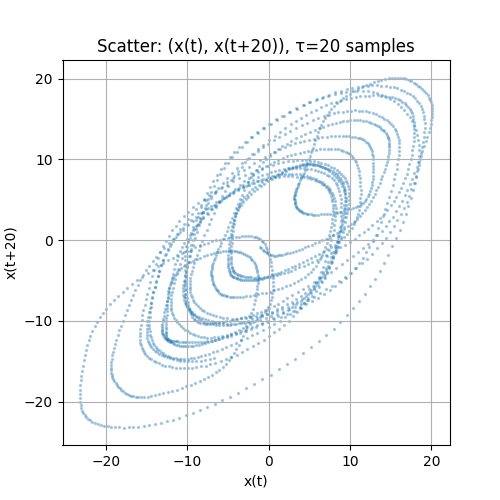

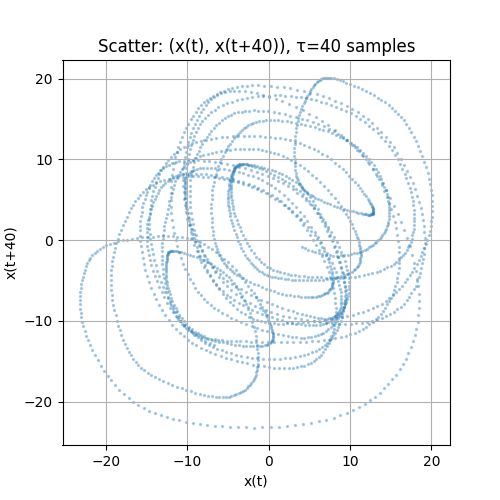

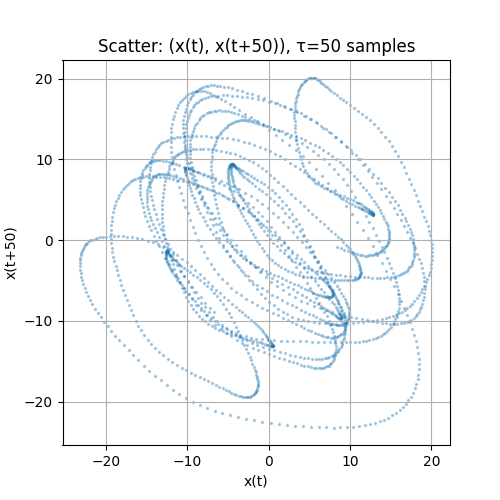

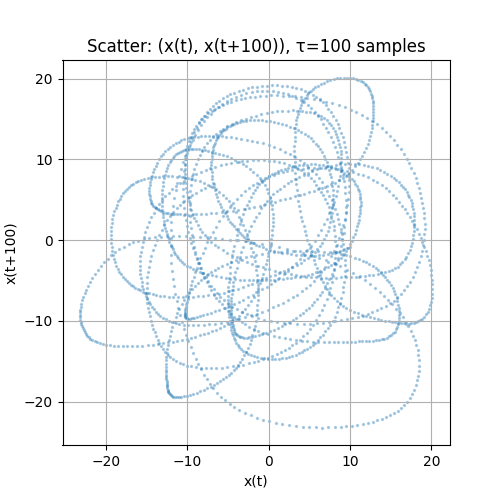


--- Axis: x ---


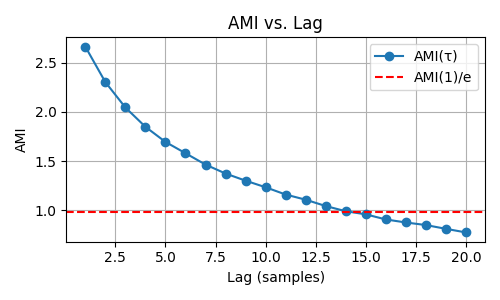

Optimal lag (τ) for axis x: 15 samples (0.150 s)


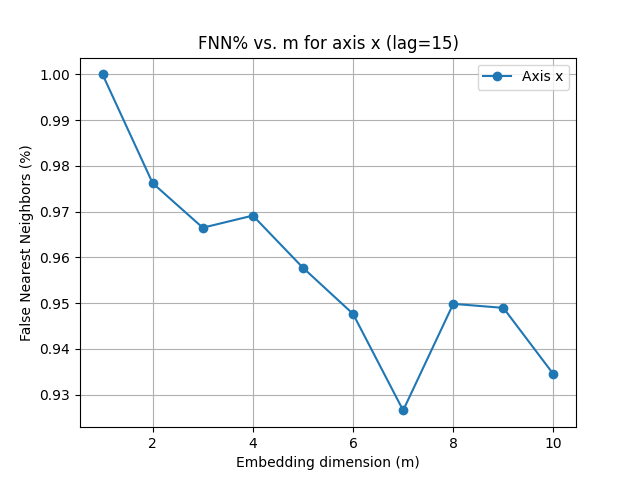

Optimal embedding dimension (m) for axis x: 7


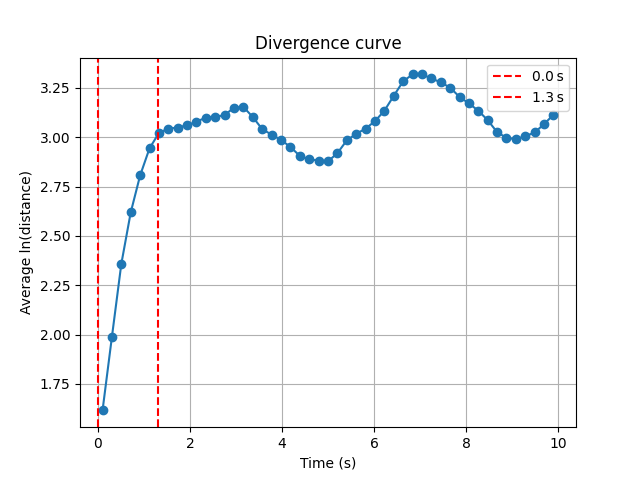

Lyapunov exponent (λ*) for axis x: 1.3094 1/s

--- Axis: z ---


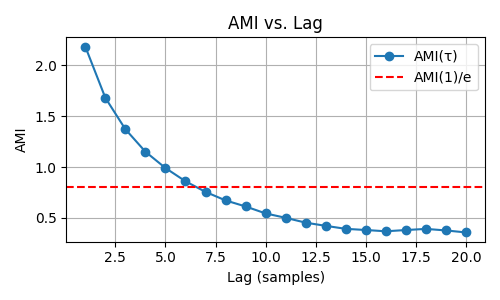

Optimal lag (τ) for axis z: 16 samples (0.160 s)


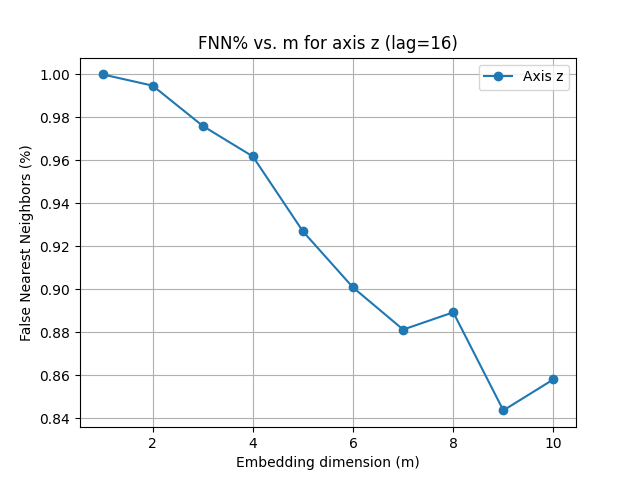

Optimal embedding dimension (m) for axis z: 9


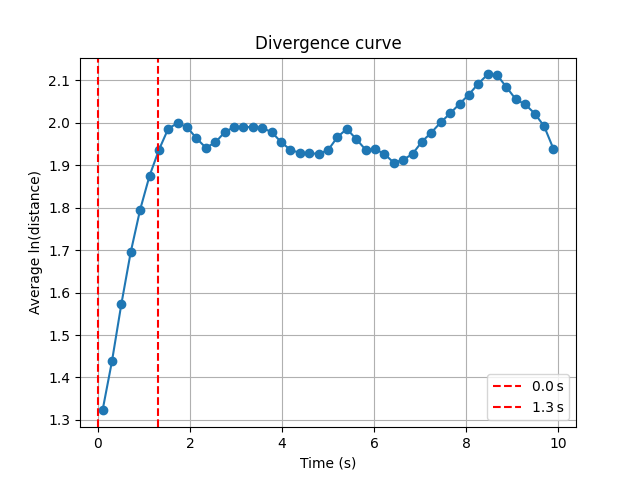

Lyapunov exponent (λ*) for axis z: 0.5540 1/s


In [15]:
from pathlib import Path
import matplotlib.pyplot as plt
import xarray as xr
import numpy as np
from scipy.stats import gaussian_kde

# Setup paths and load data
cwd = Path.cwd()
print("Current working directory:", cwd)
file_path = cwd.parent / "../data"/"CGA"/"01"/"PWS"/"4" /"markers.nc"
print("Resolved file path:       ", file_path.resolve())
print("File exists?:             ", file_path.exists())

# Load and select COM
ds_16 = xr.open_dataset(file_path)
da_16 = ds_16["markers"] if "markers" in ds_16 else ds_16
com_16 = da_16.sel(channel="COM")
time_16 = com_16.coords["time"].values  
print("Time coordinates:", time_16[0], "to", time_16[-1])

# Select time range using indices

start_idx = 447 #495
end_idx = -1
start_time_16 = time_16[start_idx]
end_time_16 = time_16[end_idx]

# Correct way to slice using time coordinate
com_16 = com_16.sel(time=slice(start_time_16, end_time_16))
print(f"Selected COM shape: {com_16.shape}")
print(f"Time range: {start_time_16} to {end_time_16}")

# ------------- Parameters -------------
max_lag = 20        # Search AMI up to 50 samples (0.50 s)
bins = 32
max_dim = 10      # Search FNN% up to 20 dimensions
rtol = 0.10
fnn_threshold = 0.80
fs = 100.0
max_time = 10.0     # Max evolution time for divergence (s)

# Assume preprocess_signal is defined
ts_x_16 = com_16.sel(axis='x').values.ravel()
ts_x_16 = preprocess_signal(ts_x_16, fs)  # Uncomment when function is defined

# 1a) Simple histogram
plt.figure(figsize=(6, 4))
plt.hist(ts_x_16, bins=50, density=True, edgecolor='k', alpha=0.6)
plt.xlabel('COM_x value')
plt.ylabel('Probability density')
plt.title('Histogram of COM_x (raw)')
plt.grid(True)
plt.show()

# 1b) Smoothed kernel-density estimate
kde_16 = gaussian_kde(ts_x_16)
xs_16 = np.linspace(ts_x_16.min(), ts_x_16.max(), 500)
plt.figure(figsize=(6, 4))
plt.hist(ts_x_16, bins=50, density=True, alpha=0.4, edgecolor='k', label='Histogram')
plt.plot(xs_16, kde_16(xs_16), 'r-', lw=2, label='KDE')  # Fixed: kde_16(xs) -> kde_16(xs_16)
plt.xlabel('COM_x value')
plt.ylabel('Probability density')
plt.title('Histogram + KDE of COM_x (raw)')
plt.legend()
plt.grid(True)
plt.show()

# Time-delay scatter plots
ts_raw_16 = com_16.sel(axis='x').values.ravel()
ts_raw_16 = preprocess_signal(ts_raw_16, fs)  # Uncomment when function is defined

for tau in [10, 20, 40, 50, 100]:  # try a few small lags
    x1 = ts_raw_16[:-tau]   # x(t)
    x2 = ts_raw_16[tau:]    # x(t + tau)

    plt.figure(figsize=(5, 5))
    plt.scatter(x1, x2, s=2, alpha=0.3)
    plt.xlabel(f'x(t)')
    plt.ylabel(f'x(t+{tau})')
    plt.title(f'Scatter: (x(t), x(t+{tau})), τ={tau} samples')
    plt.grid(True)
    plt.show()

# ------------- Process each axis separately -------------
for axis in ["x"]:
    print(f"\n--- Axis: {axis} ---")
    ts_16 = com_16.sel(axis=axis).values.ravel()

    # 1) Preprocess (detrend + 0.1–3 Hz bandpass + z-score)
    ts_16 = preprocess_signal(ts_16, fs)
    
    # 2) Find axis-specific optimal lag via AMI
    lag_16 = optimal_lag(ts_16, max_lag=max_lag, bins=bins)
    print(f"Optimal lag (τ) for axis {axis}: {lag_16} samples ({lag_16/fs:.3f} s)")
    #ts_16 =preprocess_signal(ts_16, fs, do_zscore=True )  # Ensure ts_16 is preprocessed after lag calculation
    # 3) Compute FNN% up to max_dim
    dims_16, fnn_perc_16 = compute_fnn_percentage(ts_16, lag_16, max_dim=max_dim, rtol=rtol)
    
    # 4) Plot FNN% vs. embedding dimension
    plt.figure()
    plt.plot(dims_16, fnn_perc_16, "-o", label=f"Axis {axis}")
    plt.xlabel("Embedding dimension (m)")
    plt.ylabel("False Nearest Neighbors (%)")
    plt.title(f"FNN% vs. m for axis {axis} (lag={lag_16})")
    plt.grid(True)
    plt.legend()
    plt.show()
    
    # 5) Find axis-specific embedding dimension
    dim_16 = optimal_embedding_dimension(
        ts_16, lag_16, max_dim=max_dim, rtol=rtol
    )
    print(f"Optimal embedding dimension (m) for axis {axis}: {dim_16}")
    
    # 6) Compute Lyapunov exponent for this axis
    lyap_16 = compute_lyapunov_exponent_16(ts_16, emb_dim=dim_16, lag=lag_16, fs=fs, max_time=max_time, fit_start=0.0, fit_end=1.3)
    print(f"Lyapunov exponent (λ*) for axis {axis}: {lyap_16:.4f} 1/s")

for axis in ["z"]:
    print(f"\n--- Axis: {axis} ---")
    ts_16 = com_16.sel(axis=axis).values.ravel()

    # 1) Preprocess (detrend + 0.1–3 Hz bandpass + z-score)
    ts_16 = preprocess_signal(ts_16, fs)
    
    # 2) Find axis-specific optimal lag via AMI
    lag_16 = optimal_lag(ts_16, max_lag=max_lag, bins=bins)
    print(f"Optimal lag (τ) for axis {axis}: {lag_16} samples ({lag_16/fs:.3f} s)")
    #ts_16 =preprocess_signal(ts_16, fs, do_zscore=True )  # Ensure ts_16 is preprocessed after lag calculation
    # 3) Compute FNN% up to max_dim
    dims_16, fnn_perc_16 = compute_fnn_percentage(ts_16, lag_16, max_dim=max_dim, rtol=rtol)
    
    # 4) Plot FNN% vs. embedding dimension
    plt.figure()
    plt.plot(dims_16, fnn_perc_16, "-o", label=f"Axis {axis}")
    plt.xlabel("Embedding dimension (m)")
    plt.ylabel("False Nearest Neighbors (%)")
    plt.title(f"FNN% vs. m for axis {axis} (lag={lag_16})")
    plt.grid(True)
    plt.legend()
    plt.show()
    
    # 5) Find axis-specific embedding dimension
    dim_16 = optimal_embedding_dimension(
        ts_16, lag_16, max_dim=max_dim, rtol=rtol
    )
    print(f"Optimal embedding dimension (m) for axis {axis}: {dim_16}")
    
    # 6) Compute Lyapunov exponent for this axis
    lyap_16 = compute_lyapunov_exponent_16(ts_16, emb_dim=dim_16, lag=lag_16, fs=fs, max_time=max_time, fit_start=0.0, fit_end=1.3)
    print(f"Lyapunov exponent (λ*) for axis {axis}: {lyap_16:.4f} 1/s")

Slow walking - same patient

In [27]:
# import argparse
# from pathlib import Path
# import numpy as np
# import xarray as xr
# import sys
# import os
# import matplotlib.pyplot as plt
cwd = Path.cwd()
print("Current working directory:", cwd)
file_path = cwd.parent / "../data"/"CGA"/"01"/"SWS"/"4" /"markers.nc"
print("Resolved file path:       ", file_path.resolve())
print("File exists?:             ", file_path.exists())
markers= xr.open_dataarray(file_path)
com= markers.sel(channel="COM")


%matplotlib widget

Current working directory: c:\Users\Natascha\OneDrive - Hochschule Luzern\Thesis_Dokus\DART\RepoCode\python-gaitalytics\nonlinear-metrics-calculation
Resolved file path:        C:\Users\Natascha\OneDrive - Hochschule Luzern\Thesis_Dokus\DART\RepoCode\data\CGA\01\SWS\4\markers.nc
File exists?:              True


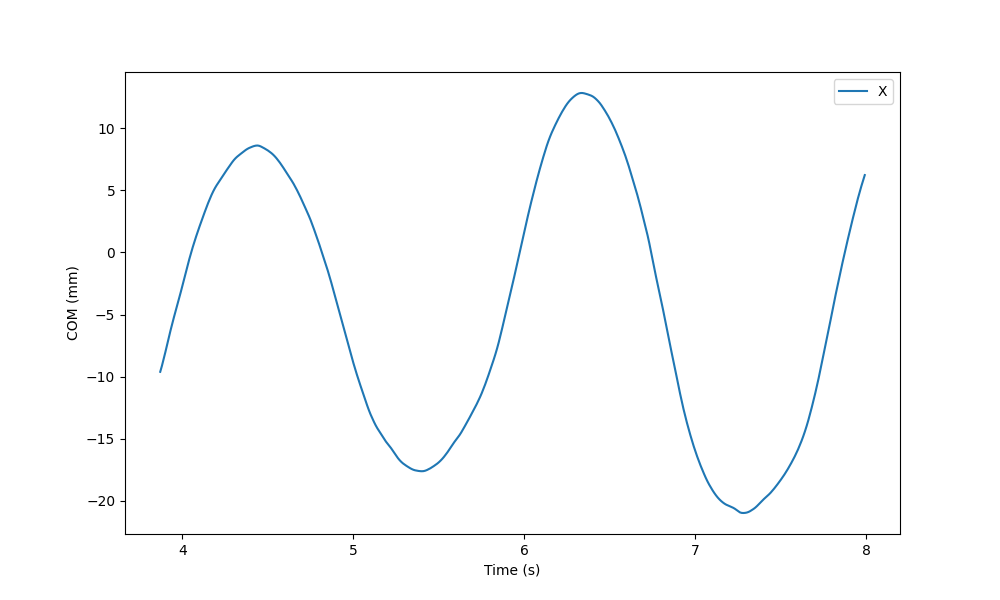

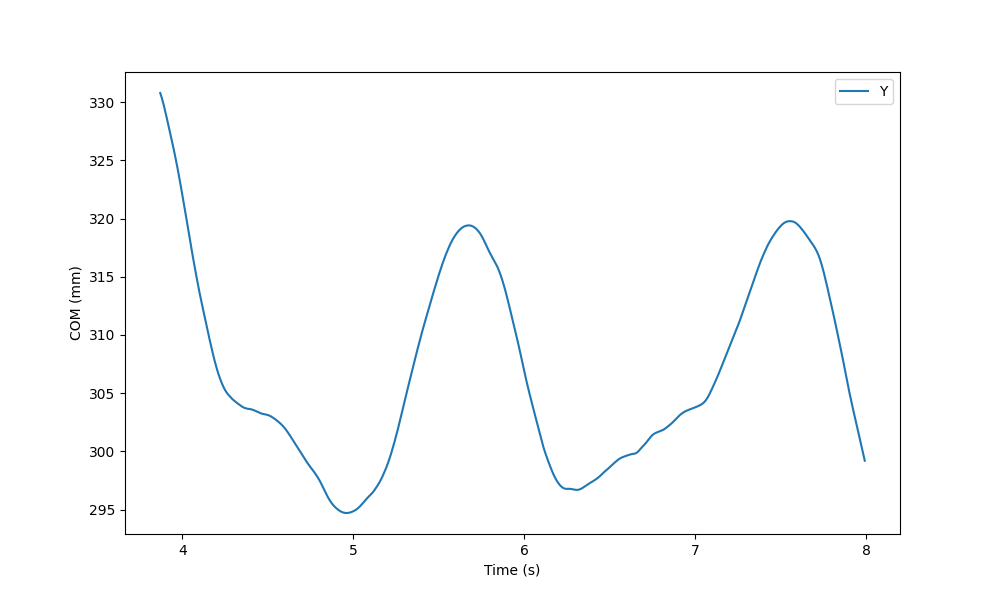

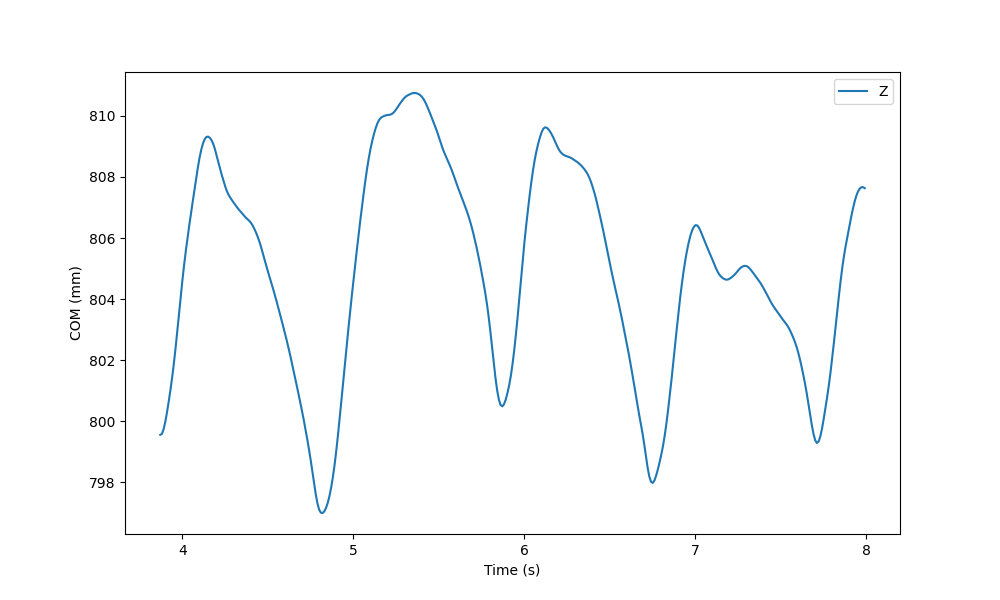

In [29]:
time = com.coords["time"].values      
# x    = preprocess_signal (com.sel(axis="x").values)       
# y    = preprocess_signal(com.sel(axis="y").values)
# z    = preprocess_signal(com.sel(axis="z").values)

x    = com.sel(axis="x").values  
y    = com.sel(axis="y").values
z    = com.sel(axis="z").values
# 1) X vs. time
fig = plt.figure(figsize=(10, 6))      
ax = fig.add_subplot(1, 1, 1)
ax.plot(time, x, label="X")
ax.set_xlabel("Time (s)")
ax.set_ylabel("COM (mm)")
ax.legend()
plt.show()

# 2) Y vs. time
fig = plt.figure(figsize=(10, 6))
ax = fig.add_subplot(1, 1, 1)
ax.plot(time, y, label="Y")
ax.set_xlabel("Time (s)")
ax.set_ylabel("COM (mm)")
ax.legend()
plt.show()

# 3) Z vs. time
fig = plt.figure(figsize=(10, 6))
ax = fig.add_subplot(1, 1, 1)
ax.plot(time, z, label="Z")
ax.set_xlabel("Time (s)")
ax.set_ylabel("COM (mm)")
ax.legend()
plt.show()

In [20]:
from pathlib import Path
import matplotlib.pyplot as plt
import xarray as xr
import numpy as np
from scipy.stats import gaussian_kde

# Setup paths and load data
cwd = Path.cwd()
print("Current working directory:", cwd)
file_path = cwd.parent / "../data"/"CGA"/"01"/"SWS"/"4" /"markers.nc"
print("Resolved file path:       ", file_path.resolve())
print("File exists?:             ", file_path.exists())

# Load and select COM
ds_Slow = xr.open_dataset(file_path)
da_Slow = ds_Slow["markers"] if "markers" in ds_Slow else ds_Slow
com_Slow = da_Slow.sel(channel="COM")
time_Slow = com_Slow.coords["time"].values  
print("Time coordinates:", time_Slow[0], "to", time_Slow[-1])

# Select time range using indices

start_idx = 116 
end_idx = -1
start_time_Slow = time_Slow[start_idx]
end_time_Slow = time_Slow[end_idx]

# Correct way to slice using time coordinate
com_Slow = com_Slow.sel(time=slice(start_time_Slow, end_time_Slow))
print(f"Selected COM shape: {com_Slow.shape}")
print(f"Time range: {start_time_Slow} to {end_time_Slow}")

# ------------- Parameters -------------
max_lag = 50        # Search AMI up to 50 samples (0.50 s)
bins = 64
max_dim = 20        # Search FNN% up to 20 dimensions
rtol = 0.15
fnn_threshold = 0.80
fs = 100.0
max_time = 10.0     # Max evolution time for divergence (s)

# Assume preprocess_signal is defined
ts_x_Slow = com_Slow.sel(axis='x').values.ravel()
ts_x_Slow = preprocess_signal(ts_x_Slow, fs)  # Uncomment when function is defined

# 1a) Simple histogram
plt.figure(figsize=(6, 4))
plt.hist(ts_x_Slow, bins=50, density=True, edgecolor='k', alpha=0.6)
plt.xlabel('COM_x value')
plt.ylabel('Probability density')
plt.title('Histogram of COM_x (raw)')
plt.grid(True)
plt.show()

# 1b) Smoothed kernel-density estimate
kde_Slow = gaussian_kde(ts_x_Slow)
xs_Slow = np.linspace(ts_x_Slow.min(), ts_x_Slow.max(), 500)
plt.figure(figsize=(6, 4))
plt.hist(ts_x_Slow, bins=50, density=True, alpha=0.4, edgecolor='k', label='Histogram')
plt.plot(xs_Slow, kde_Slow(xs_Slow), 'r-', lw=2, label='KDE')  # Fixed: kde_Slow(xs) -> kde_Slow(xs_Slow)
plt.xlabel('COM_x value')
plt.ylabel('Probability density')
plt.title('Histogram + KDE of COM_x (raw)')
plt.legend()
plt.grid(True)
plt.show()

# Time-delay scatter plots
ts_raw_Slow = com_Slow.sel(axis='x').values.ravel()
ts_raw_Slow = preprocess_signal(ts_raw_Slow, fs)  # Uncomment when function is defined

for tau in [10, 20, 40, 50, 100]:  # try a few small lags
    x1 = ts_raw_Slow[:-tau]   # x(t)
    x2 = ts_raw_Slow[tau:]    # x(t + tau)

    plt.figure(figsize=(5, 5))
    plt.scatter(x1, x2, s=2, alpha=0.3)
    plt.xlabel(f'x(t)')
    plt.ylabel(f'x(t+{tau})')
    plt.title(f'Scatter: (x(t), x(t+{tau})), τ={tau} samples')
    plt.grid(True)
    plt.show()

# ------------- Process each axis separately -------------
for axis in ["x"]:
    print(f"\n--- Axis: {axis} ---")
    ts_Slow = com_Slow.sel(axis=axis).values.ravel()

    # 1) Preprocess (detrend + 0.1–3 Hz bandpass + z-score)
    ts_Slow = preprocess_signal(ts_Slow, fs)
    
    # 2) Find axis-specific optimal lag via AMI
    lag_Slow = optimal_lag(ts_Slow, max_lag=max_lag, bins=bins)
    print(f"Optimal lag (τ) for axis {axis}: {lag_Slow} samples ({lag_Slow/fs:.3f} s)")
    #ts_Slow =preprocess_signal(ts_Slow, fs, do_zscore=True )  # Ensure ts_Slow is preprocessed after lag calculation
    # 3) Compute FNN% up to max_dim
    dims_Slow, fnn_perc_Slow = compute_fnn_percentage(ts_Slow, lag_Slow, max_dim=max_dim, rtol=rtol)
    
    # 4) Plot FNN% vs. embedding dimension
    plt.figure()
    plt.plot(dims_Slow, fnn_perc_Slow, "-o", label=f"Axis {axis}")
    plt.xlabel("Embedding dimension (m)")
    plt.ylabel("False Nearest Neighbors (%)")
    plt.title(f"FNN% vs. m for axis {axis} (lag={lag_Slow})")
    plt.grid(True)
    plt.legend()
    plt.show()
    
    # 5) Find axis-specific embedding dimension
    dim_Slow = optimal_embedding_dimension(
        ts_Slow, lag_Slow, max_dim=max_dim, rtol=rtol
    )
    print(f"Optimal embedding dimension (m) for axis {axis}: {dim_Slow}")
    
    # 6) Compute Lyapunov exponent for this axis
    lyap_Slow = compute_lyapunov_exponent(ts_Slow, emb_dim=dim_Slow, lag=lag_Slow, fs=fs, max_time=max_time, fit_start=0.0, fit_end=1.9)
    print(f"Lyapunov exponent (λ*) for axis {axis}: {lyap_Slow:.4f} 1/s")

for axis in ["z"]:
    print(f"\n--- Axis: {axis} ---")
    ts_Slow = com_Slow.sel(axis=axis).values.ravel()

    # 1) Preprocess (detrend + 0.1–3 Hz bandpass + z-score)
    ts_Slow = preprocess_signal(ts_Slow, fs)
    
    # 2) Find axis-specific optimal lag via AMI
    lag_Slow = optimal_lag(ts_Slow, max_lag=max_lag, bins=bins)
    print(f"Optimal lag (τ) for axis {axis}: {lag_Slow} samples ({lag_Slow/fs:.3f} s)")
    #ts_Slow =preprocess_signal(ts_Slow, fs, do_zscore=True )  # Ensure ts_Slow is preprocessed after lag calculation
    # 3) Compute FNN% up to max_dim
    dims_Slow, fnn_perc_Slow = compute_fnn_percentage(ts_Slow, lag_Slow, max_dim=max_dim, rtol=rtol)
    
    # 4) Plot FNN% vs. embedding dimension
    plt.figure()
    plt.plot(dims_Slow, fnn_perc_Slow, "-o", label=f"Axis {axis}")
    plt.xlabel("Embedding dimension (m)")
    plt.ylabel("False Nearest Neighbors (%)")
    plt.title(f"FNN% vs. m for axis {axis} (lag={lag_Slow})")
    plt.grid(True)
    plt.legend()
    plt.show()
    
    # 5) Find axis-specific embedding dimension
    dim_Slow = optimal_embedding_dimension(
        ts_Slow, lag_Slow, max_dim=max_dim, rtol=rtol
    )
    print(f"Optimal embedding dimension (m) for axis {axis}: {dim_Slow}")
    
    # 6) Compute Lyapunov exponent for this axis
    lyap_Slow = compute_lyapunov_exponent(ts_Slow, emb_dim=dim_Slow, lag=lag_Slow, fs=fs, max_time=max_time, fit_start=0.0, fit_end=1.9)
    print(f"Lyapunov exponent (λ*) for axis {axis}: {lyap_Slow:.4f} 1/s")

Current working directory: c:\Users\Natascha\OneDrive - Hochschule Luzern\Thesis_Dokus\DART\RepoCode\python-gaitalytics\nonlinear-metrics-calculation
Resolved file path:        C:\Users\Natascha\OneDrive - Hochschule Luzern\Thesis_Dokus\DART\RepoCode\data\CGA\01\SWS\4\markers.nc
File exists?:              True
Time coordinates: 0.0 to 189.78
Selected COM shape: (3, 18863)
Time range: 1.16 to 189.78


ValueError: array must not contain infs or NaNs

Fast walking patient - same patient

In [30]:
# import argparse
# from pathlib import Path
# import numpy as np
# import xarray as xr
# import sys
# import os
# import matplotlib.pyplot as plt
cwd = Path.cwd()
print("Current working directory:", cwd)
file_path = cwd.parent / "../data"/"CGA"/"01"/"FWS"/"4" /"markers.nc"
print("Resolved file path:       ", file_path.resolve())
print("File exists?:             ", file_path.exists())
markers= xr.open_dataarray(file_path)
com= markers.sel(channel="COM")


%matplotlib widget

Current working directory: c:\Users\Natascha\OneDrive - Hochschule Luzern\Thesis_Dokus\DART\RepoCode\python-gaitalytics\nonlinear-metrics-calculation
Resolved file path:        C:\Users\Natascha\OneDrive - Hochschule Luzern\Thesis_Dokus\DART\RepoCode\data\CGA\01\FWS\4\markers.nc
File exists?:              True


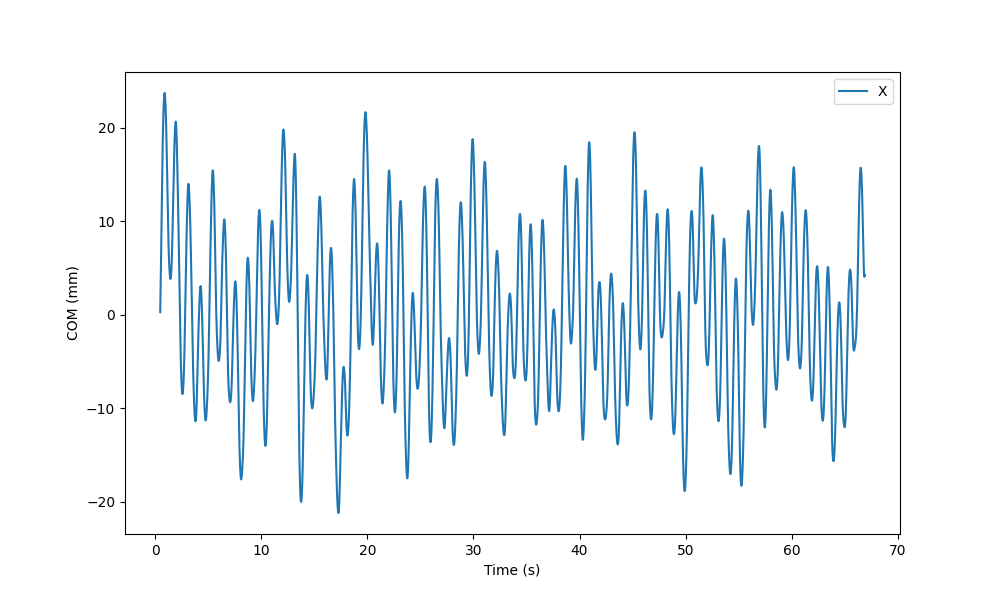

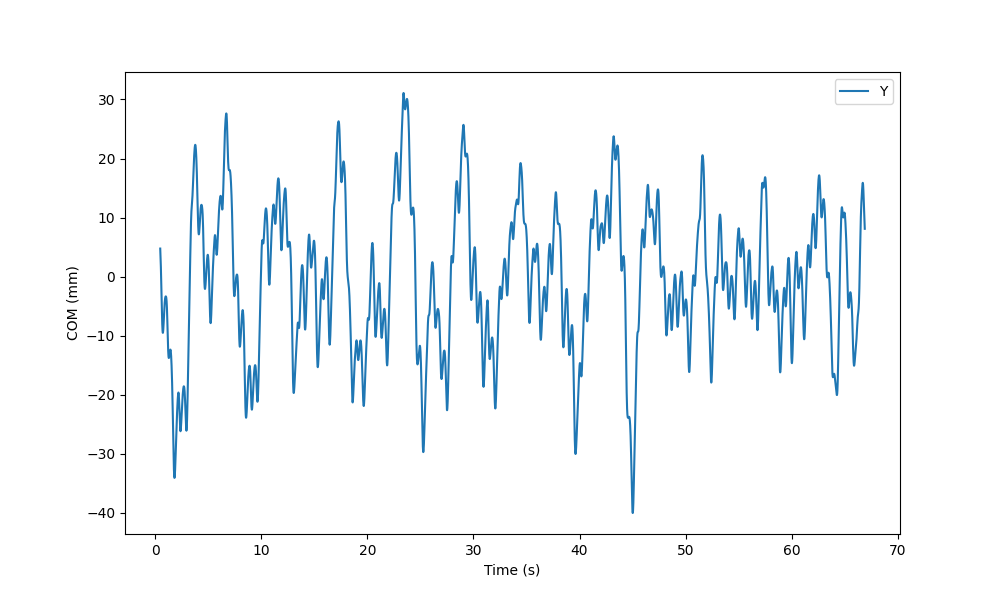

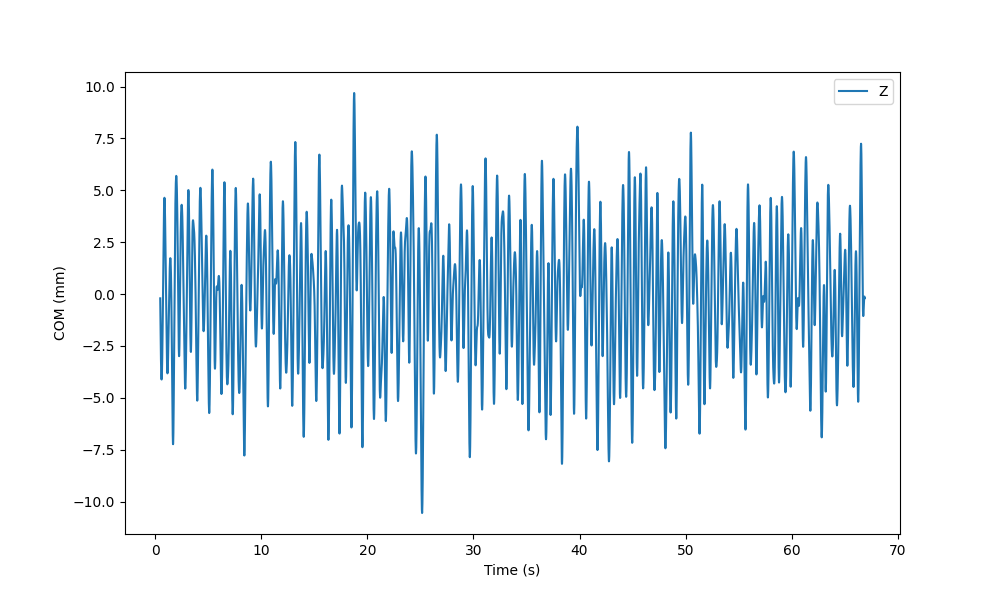

In [31]:
time = com.coords["time"].values      
x    = preprocess_signal (com.sel(axis="x").values)       
y    = preprocess_signal(com.sel(axis="y").values)
z    = preprocess_signal(com.sel(axis="z").values)

# x    = com.sel(axis="x").values  
# y    = com.sel(axis="y").values
# z    = com.sel(axis="z").values
# 1) X vs. time
fig = plt.figure(figsize=(10, 6))      
ax = fig.add_subplot(1, 1, 1)
ax.plot(time, x, label="X")
ax.set_xlabel("Time (s)")
ax.set_ylabel("COM (mm)")
ax.legend()
plt.show()

# 2) Y vs. time
fig = plt.figure(figsize=(10, 6))
ax = fig.add_subplot(1, 1, 1)
ax.plot(time, y, label="Y")
ax.set_xlabel("Time (s)")
ax.set_ylabel("COM (mm)")
ax.legend()
plt.show()

# 3) Z vs. time
fig = plt.figure(figsize=(10, 6))
ax = fig.add_subplot(1, 1, 1)
ax.plot(time, z, label="Z")
ax.set_xlabel("Time (s)")
ax.set_ylabel("COM (mm)")
ax.legend()
plt.show()

Current working directory: c:\Users\Natascha\OneDrive - Hochschule Luzern\Thesis_Dokus\DART\RepoCode\python-gaitalytics\nonlinear-metrics-calculation
Resolved file path:        C:\Users\Natascha\OneDrive - Hochschule Luzern\Thesis_Dokus\DART\RepoCode\data\CGA\01\FWS\4\markers.nc
File exists?:              True
Time coordinates: 0.48 to 66.88000000000001
Selected COM shape: (3, 6518)
Time range: 1.71 to 66.88000000000001


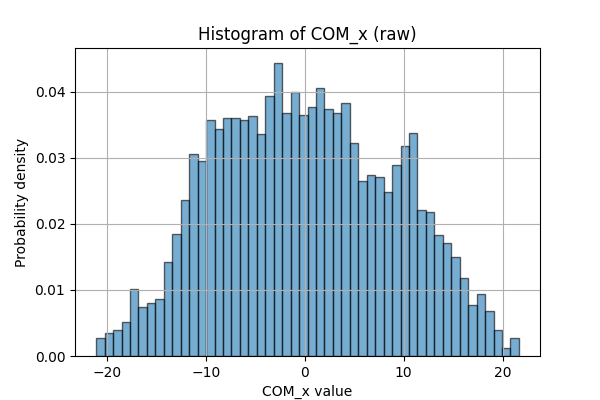

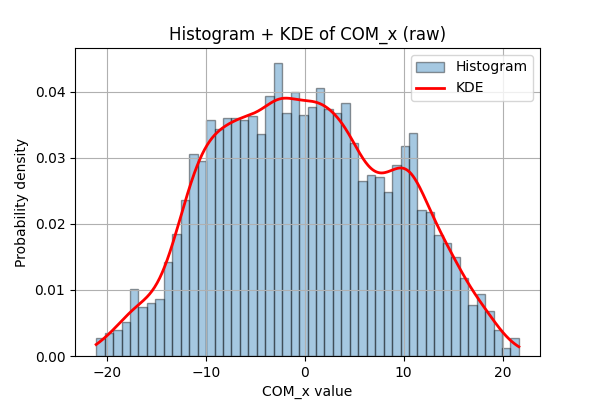

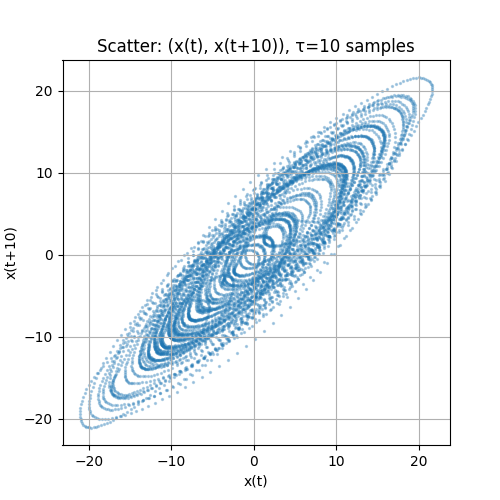

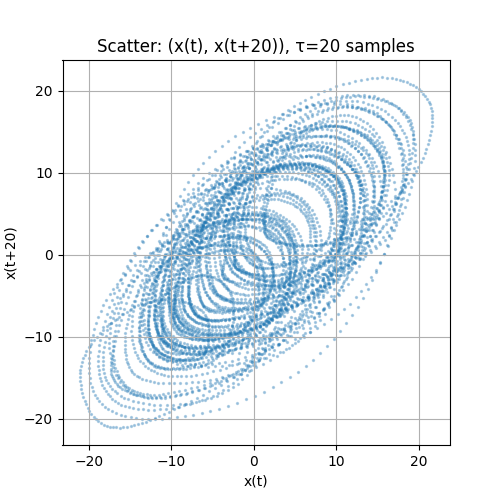

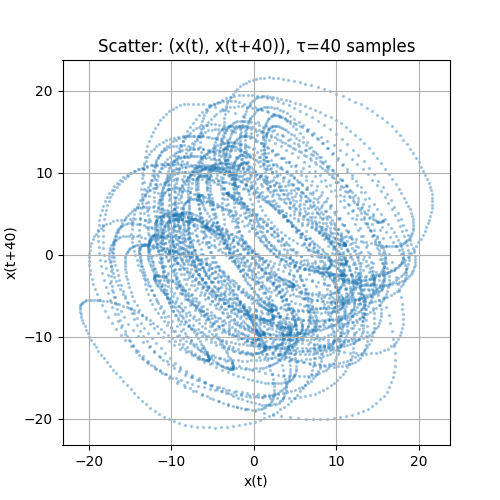

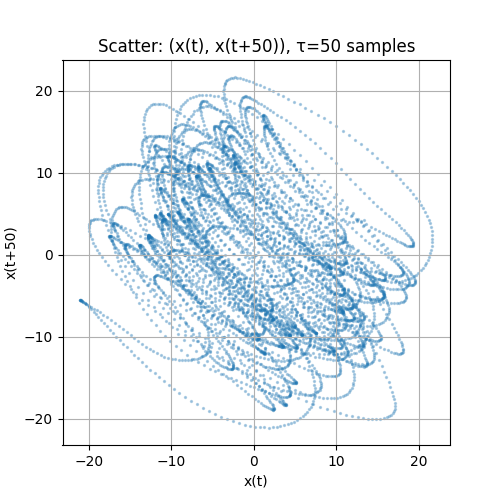

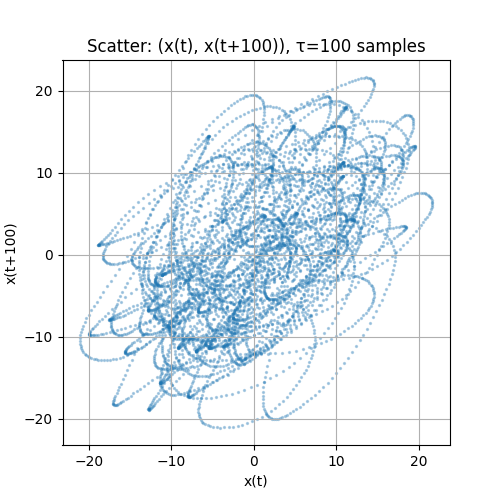


--- Axis: x ---


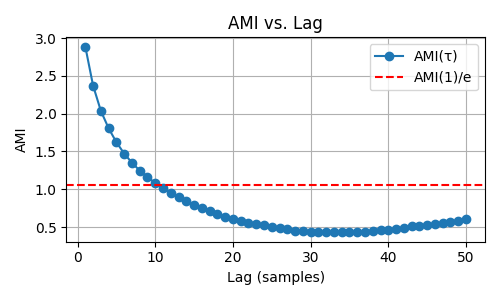

Optimal lag (τ) for axis x: 11 samples (0.110 s)


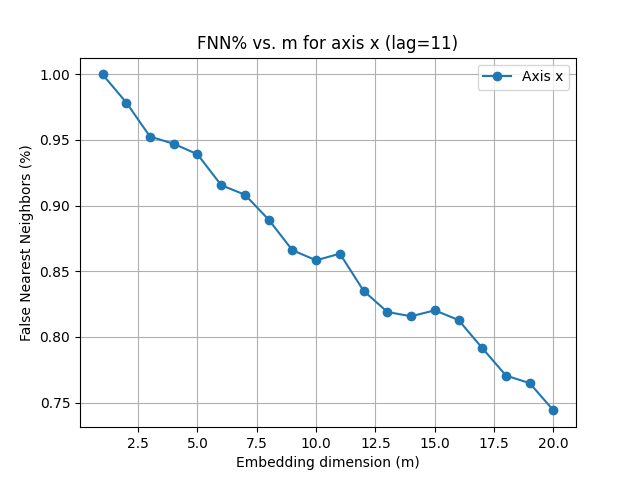

Optimal embedding dimension (m) for axis x: 11


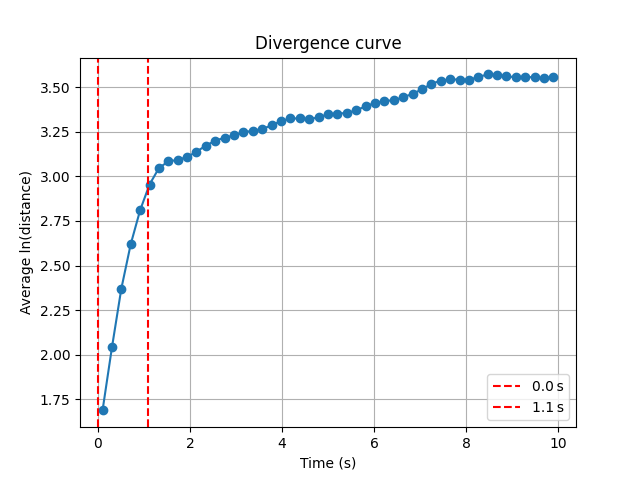

Lyapunov exponent (λ*) for axis x: 1.3847 1/s

--- Axis: z ---


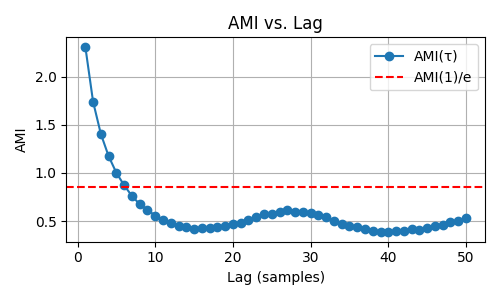

Optimal lag (τ) for axis z: 15 samples (0.150 s)


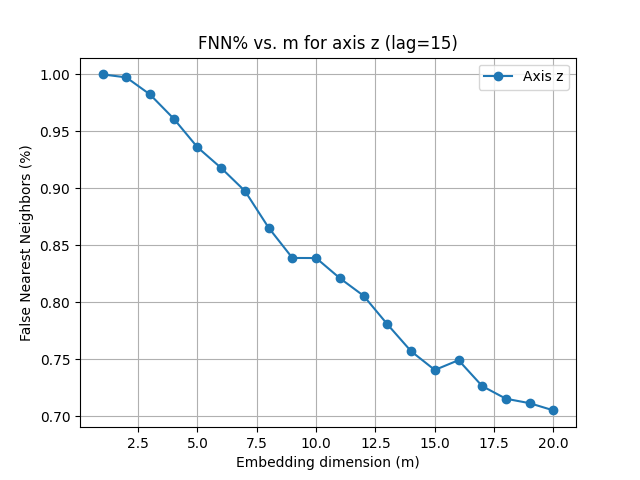

Optimal embedding dimension (m) for axis z: 16


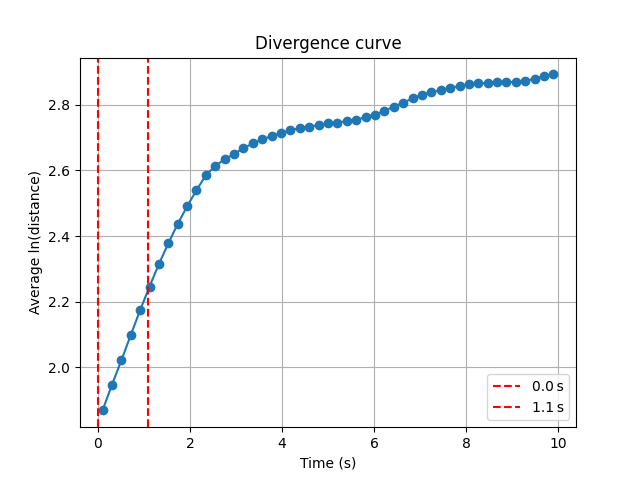

Lyapunov exponent (λ*) for axis z: 0.3729 1/s


In [36]:
# from pathlib import Path
# import matplotlib.pyplot as plt
# import xarray as xr
# import numpy as np
# from scipy.stats import gaussian_kde

# Setup paths and load data
cwd = Path.cwd()
print("Current working directory:", cwd)
file_path = cwd.parent / "../data"/"CGA"/"01"/"FWS"/"4" /"markers.nc"
print("Resolved file path:       ", file_path.resolve())
print("File exists?:             ", file_path.exists())

# Load and select COM
ds_Slow = xr.open_dataset(file_path)
da_Slow = ds_Slow["markers"] if "markers" in ds_Slow else ds_Slow
com_Slow = da_Slow.sel(channel="COM")
time_Slow = com_Slow.coords["time"].values  
print("Time coordinates:", time_Slow[0], "to", time_Slow[-1])

# Select time range using indices

start_idx = 123
end_idx = -1
start_time_Slow = time_Slow[start_idx]
end_time_Slow = time_Slow[end_idx]

# Correct way to slice using time coordinate
com_Slow = com_Slow.sel(time=slice(start_time_Slow, end_time_Slow))
print(f"Selected COM shape: {com_Slow.shape}")
print(f"Time range: {start_time_Slow} to {end_time_Slow}")

# ------------- Parameters -------------
max_lag = 50        # Search AMI up to 50 samples (0.50 s)
bins = 64
max_dim = 20        # Search FNN% up to 20 dimensions
rtol = 0.15
fnn_threshold = 0.80
fs = 100.0
max_time = 10.0     # Max evolution time for divergence (s)

# Assume preprocess_signal is defined
ts_x_Slow = com_Slow.sel(axis='x').values.ravel()
ts_x_Slow = preprocess_signal(ts_x_Slow, fs)  # Uncomment when function is defined

# 1a) Simple histogram
plt.figure(figsize=(6, 4))
plt.hist(ts_x_Slow, bins=50, density=True, edgecolor='k', alpha=0.6)
plt.xlabel('COM_x value')
plt.ylabel('Probability density')
plt.title('Histogram of COM_x (raw)')
plt.grid(True)
plt.show()

# 1b) Smoothed kernel-density estimate
kde_Slow = gaussian_kde(ts_x_Slow)
xs_Slow = np.linspace(ts_x_Slow.min(), ts_x_Slow.max(), 500)
plt.figure(figsize=(6, 4))
plt.hist(ts_x_Slow, bins=50, density=True, alpha=0.4, edgecolor='k', label='Histogram')
plt.plot(xs_Slow, kde_Slow(xs_Slow), 'r-', lw=2, label='KDE')  # Fixed: kde_Slow(xs) -> kde_Slow(xs_Slow)
plt.xlabel('COM_x value')
plt.ylabel('Probability density')
plt.title('Histogram + KDE of COM_x (raw)')
plt.legend()
plt.grid(True)
plt.show()

# Time-delay scatter plots
ts_raw_Slow = com_Slow.sel(axis='x').values.ravel()
ts_raw_Slow = preprocess_signal(ts_raw_Slow, fs)  # Uncomment when function is defined

for tau in [10, 20, 40, 50, 100]:  # try a few small lags
    x1 = ts_raw_Slow[:-tau]   # x(t)
    x2 = ts_raw_Slow[tau:]    # x(t + tau)

    plt.figure(figsize=(5, 5))
    plt.scatter(x1, x2, s=2, alpha=0.3)
    plt.xlabel(f'x(t)')
    plt.ylabel(f'x(t+{tau})')
    plt.title(f'Scatter: (x(t), x(t+{tau})), τ={tau} samples')
    plt.grid(True)
    plt.show()

# ------------- Process each axis separately -------------
for axis in ["x"]:
    print(f"\n--- Axis: {axis} ---")
    ts_Slow = com_Slow.sel(axis=axis).values.ravel()

    # 1) Preprocess (detrend + 0.1–3 Hz bandpass + z-score)
    ts_Slow = preprocess_signal(ts_Slow, fs)
    
    # 2) Find axis-specific optimal lag via AMI
    lag_Slow = optimal_lag(ts_Slow, max_lag=max_lag, bins=bins)
    print(f"Optimal lag (τ) for axis {axis}: {lag_Slow} samples ({lag_Slow/fs:.3f} s)")
    #ts_Slow =preprocess_signal(ts_Slow, fs, do_zscore=True )  # Ensure ts_Slow is preprocessed after lag calculation
    # 3) Compute FNN% up to max_dim
    dims_Slow, fnn_perc_Slow = compute_fnn_percentage(ts_Slow, lag_Slow, max_dim=max_dim, rtol=rtol)
    
    # 4) Plot FNN% vs. embedding dimension
    plt.figure()
    plt.plot(dims_Slow, fnn_perc_Slow, "-o", label=f"Axis {axis}")
    plt.xlabel("Embedding dimension (m)")
    plt.ylabel("False Nearest Neighbors (%)")
    plt.title(f"FNN% vs. m for axis {axis} (lag={lag_Slow})")
    plt.grid(True)
    plt.legend()
    plt.show()
    
    # 5) Find axis-specific embedding dimension
    dim_Slow = optimal_embedding_dimension(
        ts_Slow, lag_Slow, max_dim=max_dim, rtol=rtol
    )
    print(f"Optimal embedding dimension (m) for axis {axis}: {dim_Slow}")
    
    # 6) Compute Lyapunov exponent for this axis
    lyap_Slow = compute_lyapunov_exponent_16(ts_Slow, emb_dim=dim_Slow, lag=lag_Slow, fs=fs, max_time=max_time, fit_start=0.0, fit_end=1.1)
    print(f"Lyapunov exponent (λ*) for axis {axis}: {lyap_Slow:.4f} 1/s")

for axis in ["z"]:
    print(f"\n--- Axis: {axis} ---")
    ts_Slow = com_Slow.sel(axis=axis).values.ravel()

    # 1) Preprocess (detrend + 0.1–3 Hz bandpass + z-score)
    ts_Slow = preprocess_signal(ts_Slow, fs)
    
    # 2) Find axis-specific optimal lag via AMI
    lag_Slow = optimal_lag(ts_Slow, max_lag=max_lag, bins=bins)
    print(f"Optimal lag (τ) for axis {axis}: {lag_Slow} samples ({lag_Slow/fs:.3f} s)")
    #ts_Slow =preprocess_signal(ts_Slow, fs, do_zscore=True )  # Ensure ts_Slow is preprocessed after lag calculation
    # 3) Compute FNN% up to max_dim
    dims_Slow, fnn_perc_Slow = compute_fnn_percentage(ts_Slow, lag_Slow, max_dim=max_dim, rtol=rtol)
    
    # 4) Plot FNN% vs. embedding dimension
    plt.figure()
    plt.plot(dims_Slow, fnn_perc_Slow, "-o", label=f"Axis {axis}")
    plt.xlabel("Embedding dimension (m)")
    plt.ylabel("False Nearest Neighbors (%)")
    plt.title(f"FNN% vs. m for axis {axis} (lag={lag_Slow})")
    plt.grid(True)
    plt.legend()
    plt.show()
    
    # 5) Find axis-specific embedding dimension
    dim_Slow = optimal_embedding_dimension(
        ts_Slow, lag_Slow, max_dim=max_dim, rtol=rtol
    )
    print(f"Optimal embedding dimension (m) for axis {axis}: {dim_Slow}")
    
    # 6) Compute Lyapunov exponent for this axis
    lyap_Slow = compute_lyapunov_exponent_16(ts_Slow, emb_dim=dim_Slow, lag=lag_Slow, fs=fs, max_time=max_time, fit_start=0.0, fit_end=1.1)
    print(f"Lyapunov exponent (λ*) for axis {axis}: {lyap_Slow:.4f} 1/s")